Shape: (4601, 58)

Columns and Types:
 word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_h

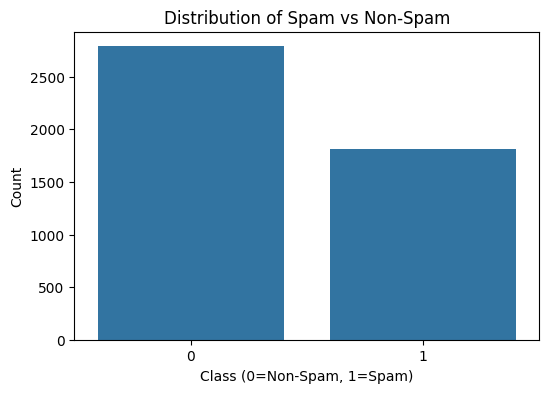

<Figure size 1000x600 with 0 Axes>

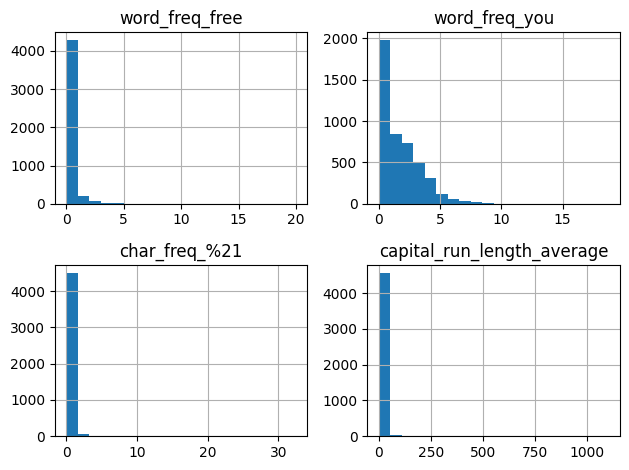

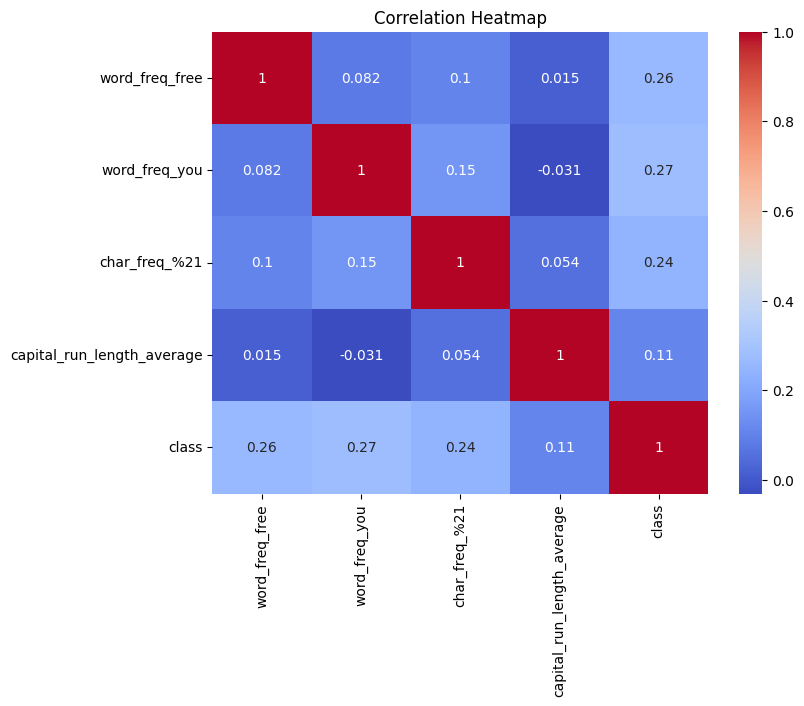

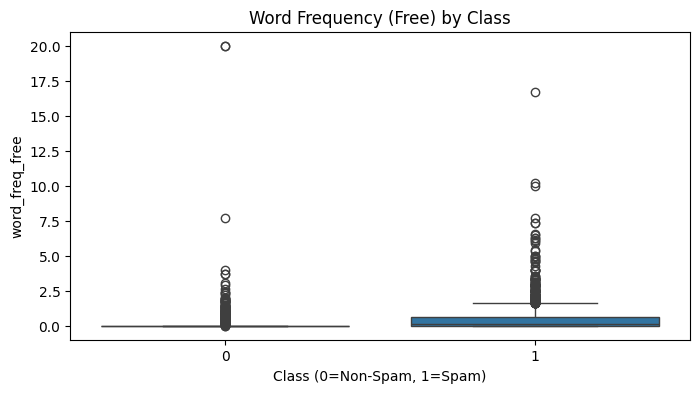


EDA Summary:
1. Dataset has 4601 rows and 58 columns.
2. No missing values.
3. Class distribution: ~40% spam, ~60% non-spam (see bar plot).
4. Features like word_freq_free and char_freq_%21 are skewed (see histograms).
5. word_freq_free correlates with spam (see heatmap, box plot).


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('spambase.csv')

print("Shape:", df.shape)
print("\nColumns and Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Distribution of Spam vs Non-Spam')
plt.xlabel('Class (0=Non-Spam, 1=Spam)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
df[['word_freq_free', 'word_freq_you', 'char_freq_%21', 'capital_run_length_average']].hist(bins=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[['word_freq_free', 'word_freq_you', 'char_freq_%21', 'capital_run_length_average', 'class']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='class', y='word_freq_free', data=df)
plt.title('Word Frequency (Free) by Class')
plt.xlabel('Class (0=Non-Spam, 1=Spam)')
plt.ylabel('word_freq_free')
plt.show()

print("\nEDA Summary:")
print("1. Dataset has", df.shape[0], "rows and", df.shape[1], "columns.")
print("2. No missing values.")
print("3. Class distribution: ~40% spam, ~60% non-spam (see bar plot).")
print("4. Features like word_freq_free and char_freq_%21 are skewed (see histograms).")
print("5. word_freq_free correlates with spam (see heatmap, box plot).")

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

Q1 = df['capital_run_length_average'].quantile(0.25)
Q3 = df['capital_run_length_average'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['capital_run_length_average'] >= Q1 - 1.5 * IQR) & (df['capital_run_length_average'] <= Q3 + 1.5 * IQR)]

X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Logistic Regression
Accuracy: 0.8244514106583072
Precision: 0.8928571428571429
Recall: 0.7692307692307693
F1-Score: 0.8264462809917356


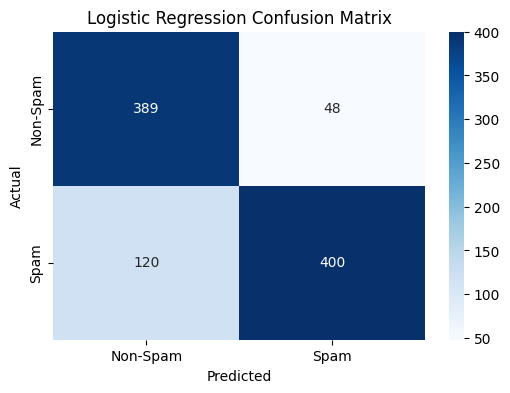


Decision Tree
Accuracy: 0.8181818181818182
Precision: 0.9119047619047619
Recall: 0.7365384615384616
F1-Score: 0.8148936170212766


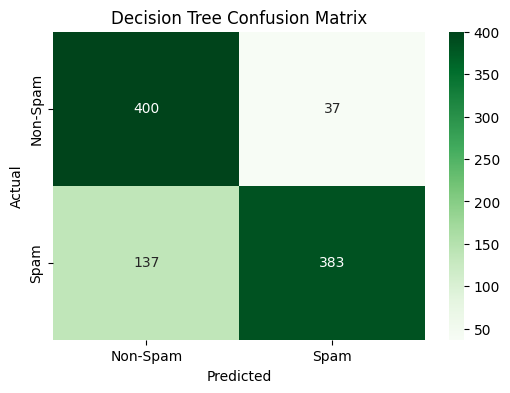


Random Forest
Accuracy: 0.8944618599791013
Precision: 0.9447983014861996
Recall: 0.8557692307692307
F1-Score: 0.8980827447023209


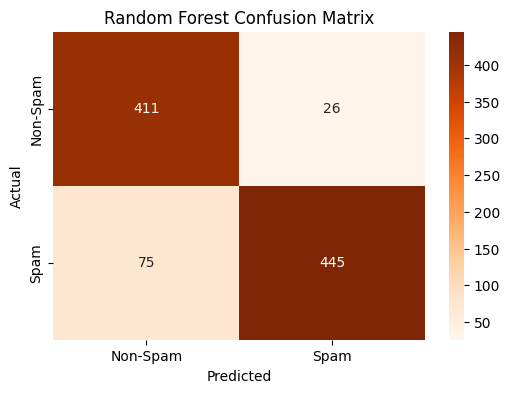

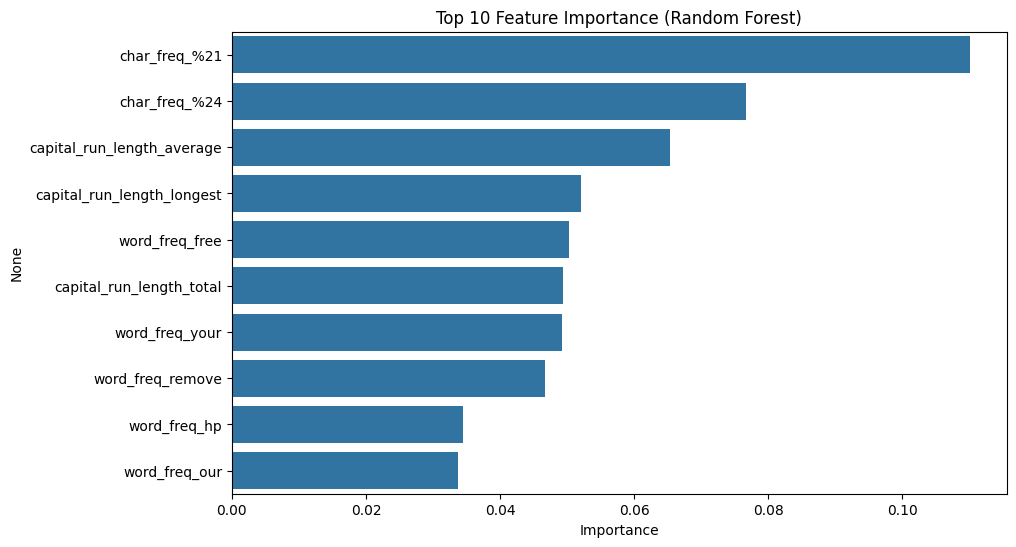

In [16]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame(X_scaled, columns=df.drop('class', axis=1).columns)
data['class'] = y
data = data.dropna()

X_clean = data.drop('class', axis=1)
y_clean = data['class']

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_clean, y_clean)

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_cm = confusion_matrix(y_test, log_pred)

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_cm = confusion_matrix(y_test, tree_pred)

forest_model = RandomForestClassifier(n_estimators=200, random_state=42)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)
forest_cm = confusion_matrix(y_test, forest_pred)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1-Score:", f1_score(y_test, log_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1-Score:", f1_score(y_test, tree_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(tree_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, forest_pred))
print("Precision:", precision_score(y_test, forest_pred))
print("Recall:", recall_score(y_test, forest_pred))
print("F1-Score:", f1_score(y_test, forest_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(forest_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(10, 6))
feature_importance = pd.Series(forest_model.feature_importances_, index=X_clean.columns).sort_values(ascending=False)[:10]
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()